In [1]:
# Libraries
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray

/mnt/ssd2/animesh/VSCode/DroughtXAIPred/venv/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in '': 'india_ll_f' (default), 'india_ll_f_'. Specify layer parameter to avoid this warning.
  result = read_func(


<Axes: >

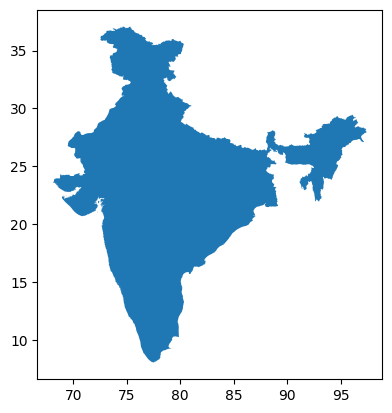

In [2]:
# Read the indian shapefile

india_shp = gpd.read_file(r"/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/Ind_shapefile/") # change the path accordingly
india_shp.plot()

In [5]:
spei = xr.open_mfdataset(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/ERA5_monthly/SPEI/*.nc', combine='by_coords')
spei

<xarray.Dataset> Size: 163MB
Dimensions:  (time: 1022, lat: 141, lon: 141)
Coordinates:
  * time     (time) datetime64[ns] 8kB 1940-01-01T06:00:00 ... 2025-02-01T06:...
  * lat      (lat) float64 1kB 40.0 39.75 39.5 39.25 39.0 ... 5.75 5.5 5.25 5.0
  * lon      (lon) float64 1kB 65.0 65.25 65.5 65.75 ... 99.25 99.5 99.75 100.0
Data variables:
    SPEI1    (time, lat, lon) float64 163MB dask.array<chunksize=(1, 141, 141), meta=np.ndarray>
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [7]:
# Process SPEI data
# The dataset already has time, lat, lon dimensions
# Convert time to year-month-day string
spei_processed = spei.copy()
spei_processed['time'] = spei_processed['time'].dt.strftime('%Y-%m-%d')

spei_processed

<xarray.Dataset> Size: 163MB
Dimensions:  (time: 1022, lat: 141, lon: 141)
Coordinates:
  * time     (time) object 8kB '1940-01-01' '1940-02-01' ... '2025-02-01'
  * lat      (lat) float64 1kB 40.0 39.75 39.5 39.25 39.0 ... 5.75 5.5 5.25 5.0
  * lon      (lon) float64 1kB 65.0 65.25 65.5 65.75 ... 99.25 99.5 99.75 100.0
Data variables:
    SPEI1    (time, lat, lon) float64 163MB dask.array<chunksize=(1, 141, 141), meta=np.ndarray>
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [8]:
t2m = xr.open_dataset(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/ERA5_monthly/AuxData/data_0.nc')
t2m

<xarray.Dataset> Size: 81MB
Dimensions:     (valid_time: 1024, latitude: 141, longitude: 141)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-04-01
    expver      (valid_time) <U4 16kB ...
  * latitude    (latitude) float64 1kB 40.0 39.75 39.5 39.25 ... 5.5 5.25 5.0
  * longitude   (longitude) float64 1kB 65.0 65.25 65.5 ... 99.5 99.75 100.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 81MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [9]:
# Process t2m data
t2m_processed = t2m.rename({'valid_time': 'time', 'latitude': 'lat', 'longitude': 'lon'})
t2m_processed = t2m_processed.drop_vars(['expver', 'number'], errors='ignore')

# Convert time to year-month-day string
t2m_processed['time'] = t2m_processed['time'].dt.strftime('%Y-%m-%d')

t2m_processed

<xarray.Dataset> Size: 81MB
Dimensions:  (time: 1024, lat: 141, lon: 141)
Coordinates:
  * time     (time) object 8kB '1940-01-01' '1940-02-01' ... '2025-04-01'
  * lat      (lat) float64 1kB 40.0 39.75 39.5 39.25 39.0 ... 5.75 5.5 5.25 5.0
  * lon      (lon) float64 1kB 65.0 65.25 65.5 65.75 ... 99.25 99.5 99.75 100.0
Data variables:
    t2m      (time, lat, lon) float32 81MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [11]:
aux = xr.open_dataset(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/ERA5_monthly/AuxData/data_1.nc')
aux

<xarray.Dataset> Size: 326MB
Dimensions:     (valid_time: 1024, latitude: 141, longitude: 141)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01T06:00:00 ... 2025-...
    expver      (valid_time) <U4 16kB ...
  * latitude    (latitude) float64 1kB 40.0 39.75 39.5 39.25 ... 5.5 5.25 5.0
  * longitude   (longitude) float64 1kB 65.0 65.25 65.5 ... 99.5 99.75 100.0
    number      int64 8B ...
Data variables:
    e           (valid_time, latitude, longitude) float32 81MB ...
    ro          (valid_time, latitude, longitude) float32 81MB ...
    tp          (valid_time, latitude, longitude) float32 81MB ...
    cdir        (valid_time, latitude, longitude) float32 81MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [12]:
# Process aux data
aux_processed = aux.rename({'valid_time': 'time', 'latitude': 'lat', 'longitude': 'lon'})
aux_processed = aux_processed.drop_vars(['expver', 'number'], errors='ignore')

# Convert time to year-month-day string
aux_processed['time'] = aux_processed['time'].dt.strftime('%Y-%m-%d')

aux_processed

<xarray.Dataset> Size: 326MB
Dimensions:  (time: 1024, lat: 141, lon: 141)
Coordinates:
  * time     (time) object 8kB '1940-01-01' '1940-02-01' ... '2025-04-01'
  * lat      (lat) float64 1kB 40.0 39.75 39.5 39.25 39.0 ... 5.75 5.5 5.25 5.0
  * lon      (lon) float64 1kB 65.0 65.25 65.5 65.75 ... 99.25 99.5 99.75 100.0
Data variables:
    e        (time, lat, lon) float32 81MB ...
    ro       (time, lat, lon) float32 81MB ...
    tp       (time, lat, lon) float32 81MB ...
    cdir     (time, lat, lon) float32 81MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [13]:
# Merge all processed datasets using outer join to handle different time dimensions
merged = xr.merge([spei_processed, t2m_processed, aux_processed], join='outer')

# Filter to keep only data up to 2024-12
merged_filtered = merged.sel(time=merged['time'] <= '2024-12-01')

merged_filtered

<xarray.Dataset> Size: 568MB
Dimensions:  (time: 1020, lat: 141, lon: 141)
Coordinates:
  * time     (time) object 8kB '1940-01-01' '1940-02-01' ... '2024-12-01'
  * lat      (lat) float64 1kB 40.0 39.75 39.5 39.25 39.0 ... 5.75 5.5 5.25 5.0
  * lon      (lon) float64 1kB 65.0 65.25 65.5 65.75 ... 99.25 99.5 99.75 100.0
Data variables:
    SPEI1    (time, lat, lon) float64 162MB dask.array<chunksize=(1, 141, 141), meta=np.ndarray>
    t2m      (time, lat, lon) float32 81MB ...
    e        (time, lat, lon) float32 81MB ...
    ro       (time, lat, lon) float32 81MB ...
    tp       (time, lat, lon) float32 81MB ...
    cdir     (time, lat, lon) float32 81MB ...
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [15]:
def plot_spei(ds):
  """
  A method to plot the basic features (mean, median, standard deviation, max, min, and a raodom time)
  """
  mean = ds.SPEI1.mean(dim = 'time')
  median = ds.SPEI1.median(dim = "time")
  max = ds.SPEI1.max(dim = "time")
  min = ds.SPEI1.min(dim = "time")
  random = ds.SPEI1.isel(time = np.random.randint(0, len(ds.SPEI1.values)))
  std = ds.SPEI1.std(dim = 'time')

  fig, axs = plt.subplots(2, 3, figsize=(12, 6))
  # Plot the mean in the first subplot
  mean.plot(ax=axs[0, 0], cmap='jet')
  axs[0, 0].set_title('Mean')
  # Plot the median in the second subplot
  median.plot(ax=axs[0, 1], cmap='jet')
  axs[0, 1].set_title('Median')
  # Plot the std days in the sixth subplot
  std.plot(ax=axs[0, 2], cmap='jet')
  axs[0, 2].set_title('Std')
  # Plot the max in the third subplot
  max.plot(ax=axs[1, 0], cmap='jet')
  axs[1, 0].set_title('Max')
  # Plot the min in the fourth subplot
  min.plot(ax=axs[1, 1], cmap='jet')
  axs[1, 1].set_title('Min')
  # Plot the random days in the fifty subplot
  random.plot(ax=axs[1, 2], cmap='jet')
  axs[1, 2].set_title('Random')

  # Adjust layout
  plt.tight_layout()

  # Show the figure
  plt.show()

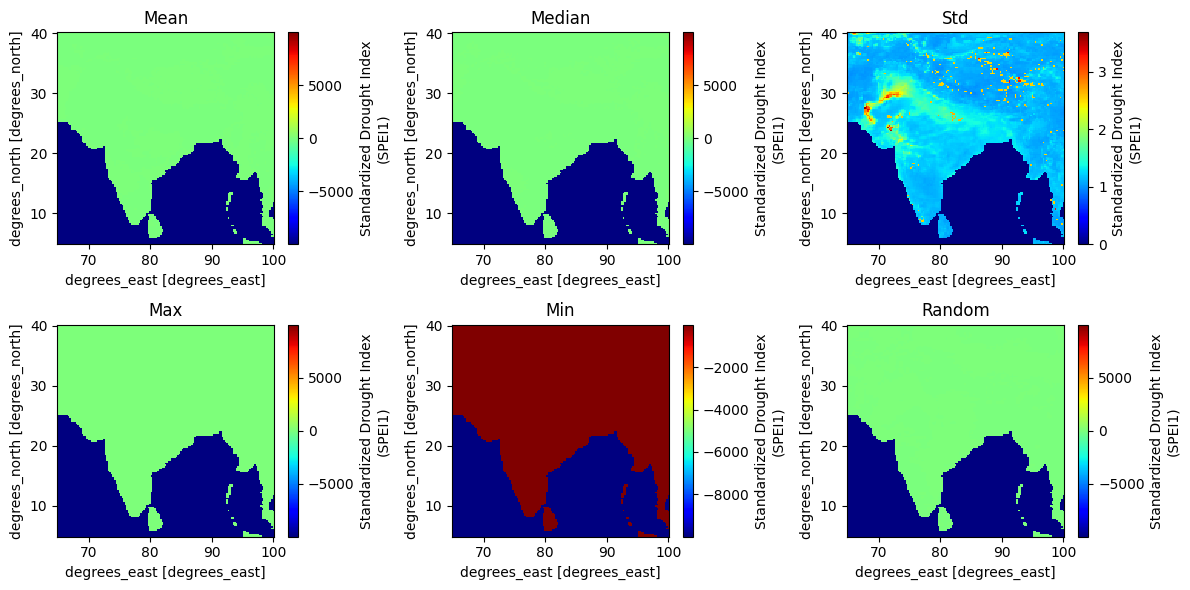

In [16]:
plot_spei(merged_filtered)

In [14]:


# Set spatial dimensions (lon=x, lat=y) for rioxarray
merged_filtered_spatial = merged_filtered.rio.set_spatial_dims(x_dim='lon', y_dim='lat')

# Write CRS and clip to shapefile
ClipData = merged_filtered_spatial.rio.write_crs(india_shp.crs).rio.clip(india_shp.geometry)

ClipData

<xarray.Dataset> Size: 388MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) object 8kB '1940-01-01' '1940-02-01' ... '2024-12-01'
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
    spatial_ref  int64 8B 0
Data variables:
    SPEI1        (time, lat, lon) float64 111MB dask.array<chunksize=(1, 116, 117), meta=np.ndarray>
    t2m          (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    e            (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    ro           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    tp           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    cdir         (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [18]:
# Set SPEI1 values to NaN where they are above 10 or below -10
ClipData_filtered = ClipData.copy()
ClipData_filtered['SPEI1'] = ClipData_filtered['SPEI1'].where((ClipData_filtered['SPEI1'] >= -10) & (ClipData_filtered['SPEI1'] <= 10))

ClipData_filtered

<xarray.Dataset> Size: 388MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) object 8kB '1940-01-01' '1940-02-01' ... '2024-12-01'
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
    spatial_ref  int64 8B 0
Data variables:
    SPEI1        (time, lat, lon) float64 111MB dask.array<chunksize=(1, 116, 117), meta=np.ndarray>
    t2m          (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    e            (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    ro           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    tp           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    cdir         (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

/mnt/ssd2/animesh/VSCode/DroughtXAIPred/venv/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


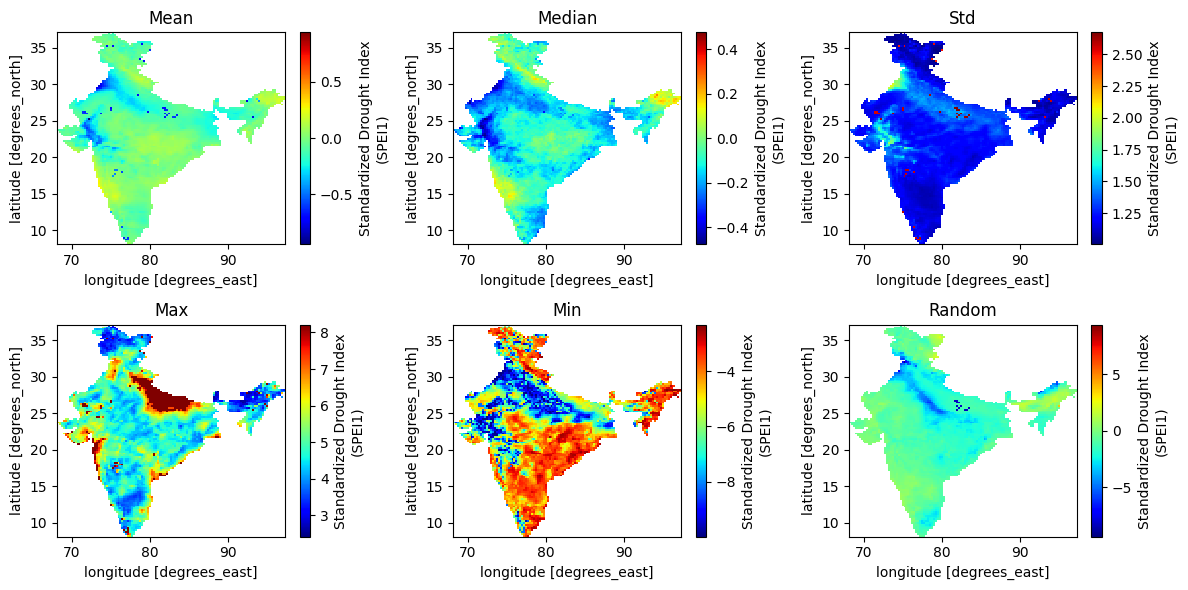

In [19]:
plot_spei(ClipData_filtered)

In [ ]:
# Classify SPEI1 values according to the classification table
def classify_spei(spei_values):
    """
    Classify SPEI values according to standard classifications:
   
    >=-0.5 : Non drought (0)
    -1.0 to -0.5: Mild drought (1)
    -1.5 to -1.0: Moderate drought (2)
    -2.0 to -1.5: Severe drought (3)
    <= -2.0: Extreme drought (4)
    """
    classified = xr.where(spei_values >= -0.5, 0, spei_values)
    # classified = xr.where((spei_values >= 1.5) & (spei_values < 2.0), 1, classified)
    # classified = xr.where((spei_values >= 1.0) & (spei_values < 1.5), 2, classified)
    # classified = xr.where((spei_values >= 0.5) & (spei_values < 1.0), 3, classified)
    # classified = xr.where((spei_values >= -0.5) & (spei_values < 0.5), 4, classified)
    classified = xr.where((spei_values >= -1.0) & (spei_values < -0.5), 1, classified)
    classified = xr.where((spei_values >= -1.5) & (spei_values < -1.0), 2, classified)
    classified = xr.where((spei_values >= -2.0) & (spei_values < -1.5), 3, classified)
    classified = xr.where(spei_values <= -2.0, 4, classified)
    return classified

# Apply classification to ClipData_filtered
ClipData_classified = ClipData_filtered.copy()
ClipData_classified['SPEI1_class'] = classify_spei(ClipData_filtered['SPEI1'])

ClipData_classified

<xarray.Dataset> Size: 498MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) object 8kB '1940-01-01' '1940-02-01' ... '2024-12-01'
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
    spatial_ref  int64 8B 0
Data variables:
    SPEI1        (time, lat, lon) float64 111MB dask.array<chunksize=(1, 116, 117), meta=np.ndarray>
    t2m          (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    e            (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    ro           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    tp           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    cdir         (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    SPEI1_class  (time, lat, lon) float64 111MB dask.array<chunksize=(1, 116, 117), meta=np.ndarray>
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [23]:
# Convert time coordinate to datetime64[ns]
ClipData_classified['time'] = ClipData_classified['time'].astype('datetime64[ns]')
ClipData_classified

<xarray.Dataset> Size: 498MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
    spatial_ref  int64 8B 0
Data variables:
    SPEI1        (time, lat, lon) float64 111MB dask.array<chunksize=(1, 116, 117), meta=np.ndarray>
    t2m          (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    e            (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    ro           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    tp           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    cdir         (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    SPEI1_class  (time, lat, lon) float64 111MB dask.array<chunksize=(1, 116, 117), meta=np.ndarray>
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [24]:
ClipData_classified.to_netcdf(r'Data\Ind_drought_ERA5_monthly_5class.nc')

In [27]:
data1 =  xr.open_dataset(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/Ind_drought_ERA5_monthly_5class.nc')
data1= data1.drop_vars(['spatial_ref'], errors='ignore')
data1

<xarray.Dataset> Size: 498MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
Data variables:
    SPEI1        (time, lat, lon) float64 111MB ...
    t2m          (time, lat, lon) float32 55MB ...
    e            (time, lat, lon) float32 55MB ...
    ro           (time, lat, lon) float32 55MB ...
    tp           (time, lat, lon) float32 55MB ...
    cdir         (time, lat, lon) float32 55MB ...
    SPEI1_class  (time, lat, lon) float64 111MB ...
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [28]:
data1.to_netcdf(r'Data\Ind_SPEI1_ERA5_monthly_5class.nc')

In [3]:
data =  xr.open_dataset(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/Ind_SPEI1_ERA5_monthly_5class.nc')
data

<xarray.Dataset> Size: 498MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
Data variables:
    SPEI1        (time, lat, lon) float64 111MB ...
    t2m          (time, lat, lon) float32 55MB ...
    e            (time, lat, lon) float32 55MB ...
    ro           (time, lat, lon) float32 55MB ...
    tp           (time, lat, lon) float32 55MB ...
    cdir         (time, lat, lon) float32 55MB ...
    SPEI1_class  (time, lat, lon) float64 111MB ...
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

# Study Area Map

In [6]:
# Add this right after loading ds — before any conversion
print("Raw tp sample values:", ds['tp'].values[:5, 50, 60])  
print("Raw tp max:", float(ds['tp'].max()))
print("Raw tp mean:", float(ds['tp'].mean()))

Raw tp sample values: [9.15527344e-05 1.33419037e-03 9.83238220e-04 1.13487244e-04
 1.26457214e-03]
Raw tp max: 0.09109878540039062
Raw tp mean: 0.0034083696082234383


Cartopy available.
Loading dataset …
Creating India mask ...
India pixels: 4641 / 13572
tp range: 0 – 12 mm/yr
t2m range: -20 – 30 °C

Class distribution (%):
  Non-drought (Class 0): 63.2%
  Mild (Class 1): 15.4%
  Moderate (Class 2): 10.9%
  Severe (Class 3): 5.9%
  Extreme (Class 4): 4.6%

Figure saved → Results/Fig1_Fig2.png


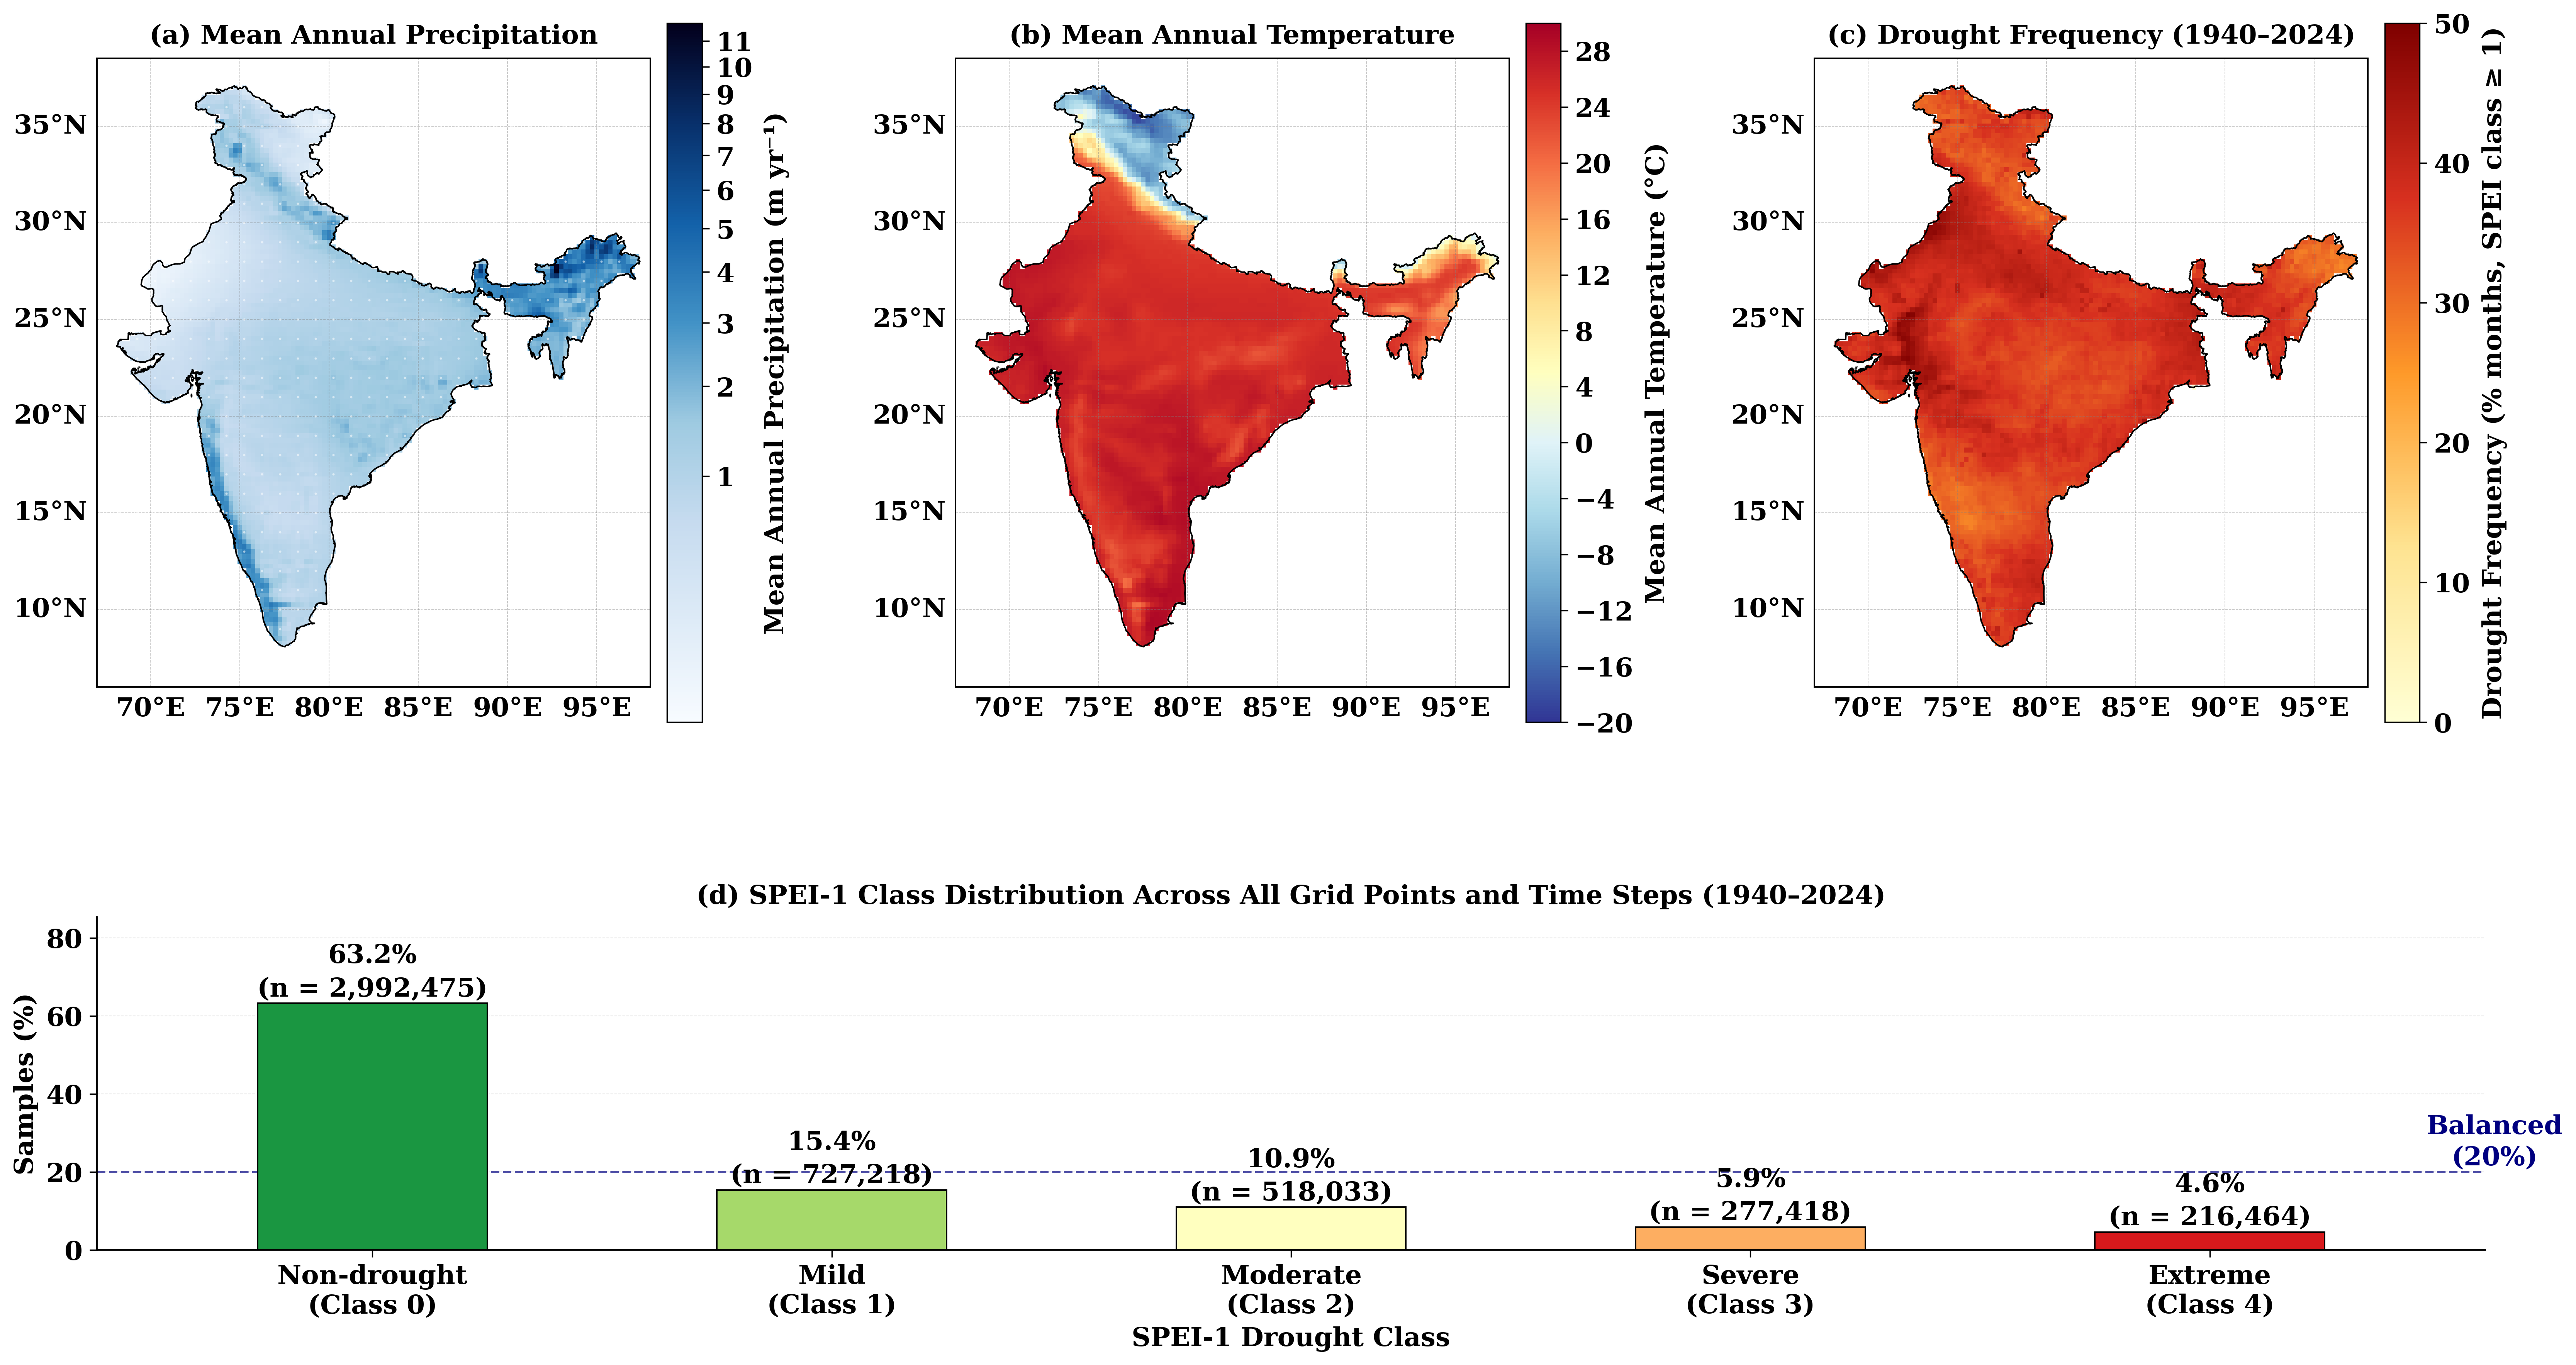

In [32]:
# =============================================================
#  Fig 1 + Fig 2  —  Study Area & SPEI-1 Climatology  [v3]
#  Changes from v2:
#    - tp: resample to annual sum first, then mean across years
#    - Panel (d) bar chart spans full second row
#    - Increased spacing between panels (wspace / hspace)
# =============================================================

import numpy as np
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
from shapely.prepared import prep
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import PowerNorm
import warnings, os
warnings.filterwarnings('ignore')

try:
    import cartopy.crs as ccrs
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    USE_CARTOPY = True
    print("Cartopy available.")
except ImportError:
    USE_CARTOPY = False
    print("Cartopy not found — plain axes mode.")

# =============================================================
# 0.  PATHS
# =============================================================
NC_PATH  = r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/Ind_SPEI1_ERA5_monthly_5class.nc'
SHP_PATH = r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/Ind_shapefile/'
OUT_PATH = r'Results/Fig1_Fig2.png'

# =============================================================
# 1.  LOAD DATA
# =============================================================
print("Loading dataset …")
ds    = xr.open_dataset(NC_PATH)
lats  = ds['lat'].values
lons  = ds['lon'].values
lon2d, lat2d = np.meshgrid(lons, lats)

india = gpd.read_file(SHP_PATH)
india = india.to_crs("EPSG:4326") if india.crs else india.set_crs("EPSG:4326")
# =============================================================
# INDIA MASK
# =============================================================
print("Creating India mask ...")

# Merge all polygons into a single geometry
india_geom = india.geometry.union_all()
india_prep = prep(india_geom)

mask = np.zeros(lon2d.shape, dtype=bool)

for i in range(lon2d.shape[0]):
    for j in range(lon2d.shape[1]):
        mask[i, j] = india_prep.contains(
            Point(lon2d[i, j], lat2d[i, j])
        )

print(f"India pixels: {mask.sum()} / {mask.size}")
# =============================================================
# 2.  DERIVED FIELDS
# =============================================================

# ── (a) Mean annual accumulated precipitation  [mm yr⁻¹]
#    tp = monthly total in metres → resample to annual sum → mean over years
# days in each month — needed to convert daily mean → monthly total
# days_in_month = ds['time'].dt.days_in_month   # (1020,) array

# # monthly total in mm = daily_mean (m/day) × days_in_month × 1000
# tp_monthly_mm = ds['tp'] * days_in_month * 1000  # (1020, 116, 117) mm/month

# # annual accumulated = sum of 12 monthly totals, then mean across years
# tp_annual     = tp_monthly_mm.resample(time='1YE').sum()   # (85, 116, 117) mm/yr
# tp_annual_mm  = tp_annual.mean(dim='time')                  # (116, 117) mm/yr     # mm yr⁻¹
# tp_vals       = tp_annual_mm.values

# ── (a) Mean annual accumulated precipitation  [m yr⁻¹]
days_in_month = ds['time'].dt.days_in_month
tp_monthly_m = ds['tp'] * days_in_month

# annual accumulated in m/year
tp_annual = tp_monthly_m.resample(time='1YE').sum()

# climatological mean annual precipitation (m/year)
tp_annual_m = tp_annual.mean(dim='time')

tp_vals = tp_annual_m.values
tp_vals = np.where(mask, tp_vals, np.nan)
# Use actual min/max precipitation values
vmin_tp = float(np.nanmin(tp_vals))
vmax_tp = float(np.nanmax(tp_vals))

print(f"tp range: {vmin_tp:.0f} – {vmax_tp:.0f} mm/yr")
# tp_p99        = float(np.nanpercentile(tp_vals[tp_vals > 0], 99))
# vmax_tp       = int(np.ceil(tp_p99 / 200) * 200)     # round up to nearest 200
# print(f"tp  range: {float(tp_vals.min()):.0f} – {float(tp_vals.max()):.0f} mm/yr  |  vmax → {vmax_tp}")

# ── (b) Mean annual temperature  [°C]
t2m_vals = (ds['t2m'].mean(dim='time') - 273.15).values
t2m_vals = np.where(mask, t2m_vals, np.nan)
t2m_vmin = int(np.floor(np.nanmin(t2m_vals) / 2) * 2)
t2m_vmax = int(np.ceil(np.nanmax(t2m_vals)  / 2) * 2)
print(f"t2m range: {t2m_vmin} – {t2m_vmax} °C")

# ── (c) Drought frequency  [%]
spei_class   = ds['SPEI1_class']
drought_freq = (spei_class >= 1).astype(float).mean(dim='time').values * 100
drought_freq = np.where(mask, drought_freq, np.nan)

# ── (d) Class distribution for bar chart
class_counts = np.array([float((spei_class == i).sum()) for i in range(5)])
class_pct    = class_counts / class_counts.sum() * 100
class_labels = ['Non-drought\n(Class 0)', 'Mild\n(Class 1)',
                'Moderate\n(Class 2)', 'Severe\n(Class 3)', 'Extreme\n(Class 4)']
print("\nClass distribution (%):")
for l, p in zip(class_labels, class_pct):
    print(f"  {l.replace(chr(10),' ')}: {p:.1f}%")

# =============================================================
# 3.  GLOBAL STYLE
# =============================================================
plt.rcParams.update({
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman', 'DejaVu Serif'],
    'font.size'         : 14,
    'font.weight'       : 'bold',
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 14,
    'axes.labelweight'  : 'bold',
    'xtick.labelsize'   : 14,
    'ytick.labelsize'   : 14,
    'axes.linewidth'    : 0.8,
    'xtick.major.width' : 0.7,
    'ytick.major.width' : 0.7,
    'xtick.major.size'  : 4,
    'ytick.major.size'  : 4,
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'savefig.dpi'       : 300,
    'figure.dpi'        : 350,
})

EXTENT = [67.0, 98.0, 6.0, 38.5]

# =============================================================
# 4.  HELPERS
# =============================================================
def style_map_ax(ax, step=5):
    """Apply India boundary, gridlines, tick labels."""
    if USE_CARTOPY:
        india.boundary.plot(ax=ax, linewidth=0.8, edgecolor='black',
                            transform=ccrs.PlateCarree(), zorder=6)
        ax.set_extent(EXTENT, crs=ccrs.PlateCarree())
        gl = ax.gridlines(draw_labels=True, linewidth=0.35,
                          color='grey', alpha=0.5, linestyle='--')
        gl.top_labels   = False
        gl.right_labels = False
        gl.xlocator     = mticker.FixedLocator(range(65, 100, step))
        gl.ylocator     = mticker.FixedLocator(range(5,  40,  step))
        gl.xlabel_style = {'size': 14, 'weight': 'bold'}
        gl.ylabel_style = {'size': 14, 'weight': 'bold'}
    else:
        india.boundary.plot(ax=ax, linewidth=0.8, edgecolor='black', zorder=6)
        ax.set_xlim(EXTENT[0], EXTENT[1])
        ax.set_ylim(EXTENT[2], EXTENT[3])
        ax.set_xlabel('Longitude (°E)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Latitude (°N)',  fontsize=11, fontweight='bold')
        ax.set_xticks(range(70, 100, step))
        ax.set_yticks(range(10, 40,  step))
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_fontweight('bold')
        ax.set_aspect('equal')
        ax.grid(True, linewidth=0.35, color='grey', alpha=0.5, linestyle='--')


def add_cbar(fig, im, ax, label, ticks, shrink=0.84, pad=0.025):
    cb = fig.colorbar(im, ax=ax, orientation='vertical',
                      shrink=shrink, pad=pad, ticks=ticks)
    cb.set_label(label, fontsize=14, fontweight='bold', labelpad=6)
    cb.ax.tick_params(labelsize=14, width=0.7, length=4)
    for t in cb.ax.get_yticklabels():
        t.set_fontweight('bold')
        t.set_fontsize(14)
    cb.outline.set_linewidth(0.7)
    return cb

# =============================================================
# 5.  FIGURE LAYOUT
#     Row 0 (tall)  : 3 map panels with gap
#     Row 1 (short) : 1 bar chart spanning full width
# =============================================================
fig = plt.figure(figsize=(19, 11))

outer = gridspec.GridSpec(
    2, 1,
    figure=fig,
    height_ratios=[5.5, 2.2],
    hspace=0.22,           # gap between map row and bar row
    left=0.04, right=0.97,
    top=0.94,  bottom=0.07,
)

# Map row — 3 panels with generous wspace
map_gs = gridspec.GridSpecFromSubplotSpec(
    1, 3,
    subplot_spec=outer[0],
    wspace=0.28,           # gap between map panels
)

if USE_CARTOPY:
    proj  = ccrs.PlateCarree()
    ax_a  = fig.add_subplot(map_gs[0, 0], projection=proj)
    ax_b  = fig.add_subplot(map_gs[0, 1], projection=proj)
    ax_c  = fig.add_subplot(map_gs[0, 2], projection=proj)
else:
    ax_a  = fig.add_subplot(map_gs[0, 0])
    ax_b  = fig.add_subplot(map_gs[0, 1])
    ax_c  = fig.add_subplot(map_gs[0, 2])

# Bar chart — full second row
ax_d  = fig.add_subplot(outer[1])

# =============================================================
# PANEL (a) — Mean Annual Accumulated Precipitation
# =============================================================
blues = LinearSegmentedColormap.from_list(
    'blues7',
    ['#f7fbff','#deebf7','#c6dbef','#9ecae1',
     '#4292c6','#1361a9','#08306b','#03001C'],
    N=256
)
# blues = LinearSegmentedColormap.from_list(
#     "india_precip",
#     [
#         "#f7fbff",
#         "#c6dbef",
#         "#6baed6",
#         "#2171b5",
#         "#1a9850",
#         "#66bd63",
#         "#d9ef8b",
#         "#fee08b",
#         "#fdae61"
#     ],
#     N=256
# )
norm =PowerNorm(gamma = 0.4)
blues = blues.copy()
blues.set_bad(color='white', alpha=0)
# tp_ticks = list(range(0, vmax_tp + 1, max(200, (vmax_tp // 8 // 200) * 200)))
tick_step = 1000  # adjust as needed
# tp_ticks = np.arange(
#     np.floor(vmin_tp / tick_step) * tick_step,
#     np.ceil(vmax_tp / tick_step) * tick_step + tick_step,
#     tick_step
# )
tp_ticks = np.arange(
    0,
    np.ceil(vmax_tp) + 1,
    1
)
im_a = ax_a.pcolormesh(lon2d, lat2d, tp_vals,
                        cmap=blues, #vmin=vmin_tp, vmax=vmax_tp,
                        shading='auto',
                        norm=norm,
                        transform=ccrs.PlateCarree() if USE_CARTOPY else None,
                        zorder=2)

# ERA5 grid overlay every 4th point
s = 4
ax_a.scatter(lon2d[::s, ::s].ravel(), lat2d[::s, ::s].ravel(),
             s=1.5, color='white', alpha=0.55, linewidths=0,
             transform=ccrs.PlateCarree() if USE_CARTOPY else None, zorder=4)

style_map_ax(ax_a)
add_cbar(fig, im_a, ax_a,
         label='Mean Annual Precipitation (m yr⁻¹)',
         ticks=tp_ticks)
ax_a.set_title('(a) Mean Annual Precipitation',
               fontsize=14, fontweight='bold', pad=8)

# =============================================================
# PANEL (b) — Mean Annual Temperature
# =============================================================
temp_cmap = plt.get_cmap('RdYlBu_r').copy()
temp_cmap.set_bad(color='white', alpha=0)
t_ticks = list(range(t2m_vmin, t2m_vmax + 1, 4))
im_b = ax_b.pcolormesh(lon2d, lat2d, t2m_vals,
                        cmap=temp_cmap,
                        vmin=t2m_vmin, vmax=t2m_vmax,
                        shading='auto',
                        transform=ccrs.PlateCarree() if USE_CARTOPY else None,
                        zorder=2)
style_map_ax(ax_b)
add_cbar(fig, im_b, ax_b,
         label='Mean Annual Temperature (°C)',
         ticks=t_ticks)
ax_b.set_title('(b) Mean Annual Temperature',
               fontsize=14, fontweight='bold', pad=8)

# =============================================================
# PANEL (c) — Drought Frequency
# =============================================================
drought_cmap = LinearSegmentedColormap.from_list(
    'drought_freq',
    ['#ffffd4','#fee391','#fe9929','#d7301f','#7f0000'],
    N=256
)
drought_cmap = drought_cmap.copy()
drought_cmap.set_bad(color='white', alpha=0)
im_c = ax_c.pcolormesh(lon2d, lat2d, drought_freq,
                        cmap=drought_cmap, vmin=0, vmax=50,
                        shading='auto',
                        transform=ccrs.PlateCarree() if USE_CARTOPY else None,
                        zorder=2)
style_map_ax(ax_c)
add_cbar(fig, im_c, ax_c,
         label='Drought Frequency (% months, SPEI class ≥ 1)',
         ticks=[0, 10, 20, 30, 40, 50])
ax_c.set_title('(c) Drought Frequency (1940–2024)',
               fontsize=14, fontweight='bold', pad=8)

# =============================================================
# PANEL (d) — Class Distribution Bar Chart (full-width row)
# =============================================================
class_colors = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']

bar_x = np.arange(5)
bars  = ax_d.bar(bar_x, class_pct,
                 color=class_colors, edgecolor='black',
                 linewidth=0.8, width=0.5, zorder=3)

# Value + count labels above each bar
for bar, pct, cnt in zip(bars, class_pct, class_counts):
    ax_d.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 0.5,
              f'{pct:.1f}%\n(n = {int(cnt):,})',
              ha='center', va='bottom',
              fontsize=14, fontweight='bold', color='black',
              linespacing=1.4)

# Reference line — balanced distribution
balanced_pct = 100 / 5
ax_d.axhline(y=balanced_pct, color='navy', linewidth=1.2,
             linestyle='--', alpha=0.7, zorder=2)
ax_d.text(4.62, balanced_pct + 0.4, 'Balanced\n(20%)',
          fontsize=14, fontweight='bold', color='navy',
          va='bottom', ha='center', linespacing=1.3)

ax_d.set_xticks(bar_x)
ax_d.set_xticklabels(class_labels, fontsize=14, fontweight='bold')
ax_d.set_ylabel('Samples (%)', fontsize=14, fontweight='bold')
ax_d.set_xlabel('SPEI-1 Drought Class', fontsize=14, fontweight='bold')
ax_d.set_ylim(0, max(class_pct) * 1.35)
ax_d.set_xlim(-0.6, 4.6)
ax_d.set_title('(d) SPEI-1 Class Distribution Across All Grid Points and Time Steps '
               '(1940–2024)',
               fontsize=14, fontweight='bold', pad=7)

for lbl in ax_d.get_xticklabels() + ax_d.get_yticklabels():
    lbl.set_fontweight('bold')
ax_d.tick_params(axis='both', labelsize=14, width=0.7, length=4)
ax_d.spines[['top', 'right']].set_visible(False)
ax_d.spines[['left', 'bottom']].set_linewidth(0.8)
ax_d.grid(axis='y', linewidth=0.4, alpha=0.5, linestyle='--', zorder=0)
ax_d.set_axisbelow(True)
ax_d.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

# =============================================================
# 6.  FIGURE CAPTION
# =============================================================
# fig.text(
#     0.5, 0.005,
#     'Figure 1. Climatological overview of the study area. '
#     '(a) Mean annual accumulated precipitation (mm yr⁻¹); white dots indicate ERA5 0.25° grid points (~13,572 pixels). '
#     '(b) Mean annual 2 m air temperature (°C). '
#     '(c) Spatial distribution of drought frequency (percentage of months with SPEI-1 class ≥ 1, 1940–2024). '
#     '(d) Overall distribution of SPEI-1 drought classes across all grid-point–month combinations; '
#     'the dashed line indicates the expected frequency under a perfectly balanced class distribution (20%).',
#     ha='center', va='bottom', fontsize=8, style='italic', color='#222222',
# )

# =============================================================
# 7.  SAVE
# =============================================================
os.makedirs('Results', exist_ok=True)
plt.savefig(OUT_PATH, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print(f"\nFigure saved → {OUT_PATH}")
plt.show()